### Ex3.1

1\.a Make a new directory called `students` in your home. Download a csv file with the list of students of this lab from [here](https://www.dropbox.com/s/867rtx3az6e9gm8/LCP_22-23_students.csv) (use the `wget` command) and copy that to `students`. First check whether the file is already there \

1\.b Make two new files, one containing the students belonging to PoD, the other to Physics. \

1\.c For each letter of the alphabet, count the number of students whose surname starts with that letter. \

1\.d Find out which is the letter with most counts. \

1\.e Assume an obvious numbering of the students in the file (first line is 1, second line is 2, etc.), group students "modulo 18", i.e. 1,19,37,.. 2,20,38,.. etc. and put each group in a separate file  

In [11]:
'''
%%bash
pwd
git branch --show-current
git status --shor
'''

'\n%%bash\npwd\ngit branch --show-current\ngit status --shor\n'

In [2]:
'''

%%writefile ex3_1_students.sh
#!/bin/bash

# Exercise 3.1 — Bash student list processing

# 1.a Create students directory in home
mkdir -p "$HOME/students"

# Go to the students directory
cd "$HOME/students" || exit

# Define file name and URL
file="LCP_22-23_students.csv"
url="https://www.dropbox.com/s/867rtx3az6e9gm8/LCP_22-23_students.csv"

# Check whether the file is already there
if [ -f "$file" ]; then
    echo "$file already exists."
else
    echo "$file not found. Downloading..."
    wget -O "$file" "$url"
fi

# 1.b Create two files: PoD students and Physics students
grep "PoD" "$file" > students_PoD.csv
grep "Physics" "$file" > students_Physics.csv

# 1.c Count how many surnames start with each letter
> surname_counts.txt

for letter in {A..Z}
do
    count=$(awk -F',' -v l="$letter" 'toupper($1) ~ "^"l {count++} END {print count+0}' "$file")
    echo "$letter $count" >> surname_counts.txt
done

# 1.d Find the letter with the maximum count
sort -k2 -nr surname_counts.txt | head -n 1 > most_common_letter.txt

# 1.e Group students modulo 18
rm -f group_*.txt

awk -F',' '
{
    group = ((NR - 1) % 18) + 1
    print $0 >> "group_" group ".txt"
}
' "$file"

echo "Exercise 3.1 completed."
'''

Writing ex3_1_students.sh


In [40]:
%%writefile ex3_1_students.sh
#!/bin/bash

set -e

# Exercise 3.1 — Final clean exam-style solution

# 1.a Create students directory in home
mkdir -p "$HOME/students"

# Define file and URL
file="$HOME/students/LCP_22-23_students.csv"
url="https://www.dropbox.com/s/867rtx3az6e9gm8/LCP_22-23_students.csv?dl=1"

# Download file only if it is not already there
if [ -f "$file" ]; then
    echo "CSV file already exists."
else
    echo "CSV file not found. Downloading..."

    if command -v wget >/dev/null 2>&1; then
        wget -O "$file" "$url"
    else
        curl -L -o "$file" "$url"
    fi
fi

# 1.b Create files for PoD and Physics students
awk -F',' 'NR > 1 && $4 == "PoD" {print $0}' "$file" > "$HOME/students/students_PoD.csv"
awk -F',' 'NR > 1 && $4 == "Physics" {print $0}' "$file" > "$HOME/students/students_Physics.csv"

# 1.c Count students whose surname starts with each letter
> "$HOME/students/surname_counts.txt"

for letter in {A..Z}
do
    awk -F',' -v letter="$letter" '
    NR > 1 {
        first_letter = toupper(substr($1, 1, 1))
        if (first_letter == letter) {
            count++
        }
    }
    END {
        print letter, count + 0
    }
    ' "$file" >> "$HOME/students/surname_counts.txt"
done

# 1.d Find the most common surname starting letter
sort -k2,2nr "$HOME/students/surname_counts.txt" | head -n 1 > "$HOME/students/most_common_letter.txt"

# 1.e Split students into 18 groups using modulo 18
awk -F',' '
NR > 1 {
    group = ((NR - 2) % 18) + 1
    print $0 > ENVIRON["HOME"] "/students/group_" group ".txt"
}
' "$file"

echo "Exercise 3.1 completed."

Overwriting ex3_1_students.sh


In [41]:
!bash -lc 'bash ex3_1_students.sh'

CSV file already exists.
Exercise 3.1 completed.


In [45]:
!bash -lc 'ls "$HOME/students"/group_*.txt | wc -l'

18


In [46]:
!bash -lc 'cat "$HOME/students/most_common_letter.txt"'

B 13


In [47]:
!bash -lc 'wc -l "$HOME/students/students_PoD.csv"'

67 /c/Users/sisto/students/students_PoD.csv


In [48]:
!bash -lc 'wc -l "$HOME/students/students_Physics.csv"'

5 /c/Users/sisto/students/students_Physics.csv


### Ex3.2
2.a Make a copy of the file `data.csv` removing the metadata and the commas between numbers; call it `data.txt` \
2\.b How many even numbers are there? \
2\.c Distinguish the entries on the basis of `sqrt(X^2 + Y^2 + Z^2)` is greater or smaller than `100*sqrt(3)/2`. Count the entries of each of the two groups \
2\.d Make `n` copies of data.txt (with `n` an input parameter of the script), where the i-th copy has all the numbers divided by i (with `1<=i<=n`).

In [ ]:
#!bash -lc 'ls -lh data.csv'

In [15]:
%%writefile data.csv
# metadata: example file for practice
# columns are X,Y,Z
X,Y,Z
10,20,30
50,50,50
100,0,0
90,90,90
2,4,6
3,5,7

Writing data.csv


In [17]:
%%writefile ex3_2_data.sh
#!/bin/bash

set -e

# Exercise 3.2 — Final clean Bash solution

# n is the input parameter
n="$1"

# Check input parameter
if [ -z "$n" ]; then
    echo "Usage: bash ex3_2_data.sh n"
    exit 1
fi

# Input and output files
input="data.csv"
output="data.txt"

# Check that data.csv exists
if [ ! -f "$input" ]; then
    echo "Error: data.csv not found."
    exit 1
fi

# 2.a Remove metadata and commas; create data.txt
# Keep only rows where the first three fields are numbers
awk -F',' '
$1 ~ /^-?[0-9]+(\.[0-9]+)?$/ &&
$2 ~ /^-?[0-9]+(\.[0-9]+)?$/ &&
$3 ~ /^-?[0-9]+(\.[0-9]+)?$/ {
    print $1, $2, $3
}
' "$input" > "$output"

# 2.b Count even numbers in data.txt
awk '
{
    for (i = 1; i <= NF; i++) {
        if ($i == int($i) && $i % 2 == 0) {
            count++
        }
    }
}
END {
    print count
}
' "$output" > even_count.txt

# 2.c Split rows according to distance from origin
awk '
BEGIN {
    threshold = 100 * sqrt(3) / 2
}
{
    x = $1
    y = $2
    z = $3

    distance = sqrt(x*x + y*y + z*z)

    if (distance > threshold) {
        print $0 > "data_greater.txt"
        greater++
    } else {
        print $0 > "data_smaller.txt"
        smaller++
    }
}
END {
    print "greater", greater + 0 > "distance_counts.txt"
    print "smaller_or_equal", smaller + 0 >> "distance_counts.txt"
}
' "$output"

# 2.d Make n copies of data.txt
# In the i-th copy, all numbers are divided by i
for ((i = 1; i <= n; i++))
do
    awk -v divisor="$i" '
    {
        for (j = 1; j <= NF; j++) {
            printf "%g", $j / divisor

            if (j < NF) {
                printf " "
            } else {
                printf "\n"
            }
        }
    }
    ' "$output" > "data_divided_by_${i}.txt"
done

echo "Exercise 3.2 completed."


Writing ex3_2_data.sh


In [18]:
!bash -lc 'bash ex3_2_data.sh 5'

Exercise 3.2 completed.


In [19]:
!bash -lc 'cat data.txt'

10 20 30
50 50 50
100 0 0
90 90 90
2 4 6
3 5 7


In [20]:
!bash -lc 'cat distance_counts.txt'

greater 2
smaller_or_equal 4


In [21]:
!bash -lc 'ls data_divided_by_*.txt'

data_divided_by_1.txt
data_divided_by_2.txt
data_divided_by_3.txt
data_divided_by_4.txt
data_divided_by_5.txt


### Ex4.2
2\. Find the outer product of the following two vecotrs
```python
u = np.array([1,3,5,7])
v = np.array([2,4,6,8])
```
Do this in the following ways:
   * Using the function outer in numpy
   * Using a nested for loop or list comprehension
   * Using numpy broadcasting operatoins

In [1]:
import numpy as np

u = np.array([1, 3, 5, 7])
v = np.array([2, 4, 6, 8])

# Method 1: using np.outer
outer_1 = np.outer(u, v)

# Method 2: using list comprehension
outer_2 = np.array([[i * j for j in v] for i in u])

# Method 3: using broadcasting
outer_3 = u[:, np.newaxis] * v[np.newaxis, :]

print("Using np.outer:")
print(outer_1)

print("\nUsing list comprehension:")
print(outer_2)

print("\nUsing broadcasting:")
print(outer_3)

print("\nAll methods give the same result:")
print(np.array_equal(outer_1, outer_2) and np.array_equal(outer_1, outer_3))

Using np.outer:
[[ 2  4  6  8]
 [ 6 12 18 24]
 [10 20 30 40]
 [14 28 42 56]]

Using list comprehension:
[[ 2  4  6  8]
 [ 6 12 18 24]
 [10 20 30 40]
 [14 28 42 56]]

Using broadcasting:
[[ 2  4  6  8]
 [ 6 12 18 24]
 [10 20 30 40]
 [14 28 42 56]]

All methods give the same result:
True


### Ex4.4
4\. Use np.linspace to create an array of 100 numbers between 0 and 2π (includsive).
  * Extract every 10th element using slice notation
  * Reverse the array using slice notation
  * Extract elements where the absolute difference between the sine and cosine functions evaluated at that element is less than 0.1
  * Make a plot showing the sin and cos functions and indicate where they are close

Original array shape: (100,)

Every 10th element:
[0.         0.63466518 1.26933037 1.90399555 2.53866073 3.17332591
 3.8079911  4.44265628 5.07732146 5.71198664]

Reversed array, first 10 elements:
[6.28318531 6.21971879 6.15625227 6.09278575 6.02931923 5.96585272
 5.9023862  5.83891968 5.77545316 5.71198664]

Values of x where |sin(x) - cos(x)| < 0.1:
[0.76159822 0.82506474 3.87145761 3.93492413]


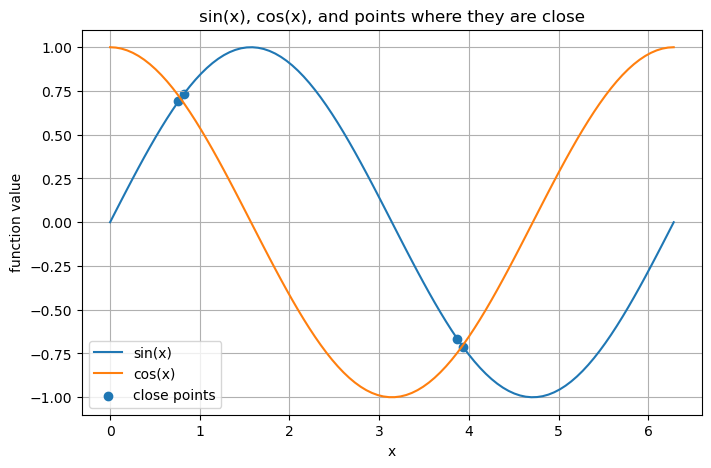

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create 100 numbers between 0 and 2π included
x = np.linspace(0, 2*np.pi, 100)

# 2. Extract every 10th element
every_10th = x[::10]

# 3. Reverse the array
x_reversed = x[::-1]

# 4. Find elements where sin(x) and cos(x) are close
sin_x = np.sin(x)
cos_x = np.cos(x)

close_mask = np.abs(sin_x - cos_x) < 0.1
x_close = x[close_mask]
sin_close = sin_x[close_mask]

# Print results
print("Original array shape:", x.shape)
print("\nEvery 10th element:")
print(every_10th)

print("\nReversed array, first 10 elements:")
print(x_reversed[:10])

print("\nValues of x where |sin(x) - cos(x)| < 0.1:")
print(x_close)

# 5. Plot sin and cos and mark close points
plt.figure(figsize=(8, 5))

plt.plot(x, sin_x, label="sin(x)")
plt.plot(x, cos_x, label="cos(x)")

plt.scatter(x_close, sin_close, label="close points")

plt.xlabel("x")
plt.ylabel("function value")
plt.title("sin(x), cos(x), and points where they are close")
plt.legend()
plt.grid(True)

plt.show()

### Ex4.6

6\. Use broadcasting to create a grid of distances

Route 66 crosses the following cities in the US: Chicago, Springfield, Saint-Louis, Tulsa, Oklahoma City, Amarillo, Santa Fe, Albuquerque, Flagstaff, Los Angeles
The corresponding positions in miles are: 0, 198, 303, 736, 871, 1175, 1475, 1544, 1913, 2448

  * Construct a 2D grid of distances among each city along Route 66
  * Convert that in km (those savages...)

In [19]:
import numpy as np

# City names
cities = np.array([
    "Chicago", "Springfield", "Saint-Louis", "Tulsa", "Oklahoma City",
    "Amarillo", "Santa Fe", "Albuquerque", "Flagstaff", "Los Angeles"
])

# Positions along Route 66 in miles
positions_miles = np.array([0, 198, 303, 736, 871, 1175, 1475, 1544, 1913, 2448])

# 1. Create a 2D grid of distances in miles using broadcasting
distances_miles = np.abs(positions_miles[:, np.newaxis] - positions_miles[np.newaxis, :])

# 2. Convert miles to kilometers
distances_km = distances_miles * 1.609344

print("Distance grid in miles:")
print(distances_miles)

print("\nDistance grid in km:")
print(distances_km)

Distance grid in miles:
[[   0  198  303  736  871 1175 1475 1544 1913 2448]
 [ 198    0  105  538  673  977 1277 1346 1715 2250]
 [ 303  105    0  433  568  872 1172 1241 1610 2145]
 [ 736  538  433    0  135  439  739  808 1177 1712]
 [ 871  673  568  135    0  304  604  673 1042 1577]
 [1175  977  872  439  304    0  300  369  738 1273]
 [1475 1277 1172  739  604  300    0   69  438  973]
 [1544 1346 1241  808  673  369   69    0  369  904]
 [1913 1715 1610 1177 1042  738  438  369    0  535]
 [2448 2250 2145 1712 1577 1273  973  904  535    0]]

Distance grid in km:
[[   0.        318.650112  487.631232 1184.477184 1401.738624 1890.9792
  2373.7824   2484.827136 3078.675072 3939.674112]
 [ 318.650112    0.        168.98112   865.827072 1083.088512 1572.329088
  2055.132288 2166.177024 2760.02496  3621.024   ]
 [ 487.631232  168.98112     0.        696.845952  914.107392 1403.347968
  1886.151168 1997.195904 2591.04384  3452.04288 ]
 [1184.477184  865.827072  696.845952    0.       

### Ex4.8
8\. Diffusion using random walk

Consider a simple random walk process: at each step in time, a walker jumps right or left (+1 or -1) with equal probability. The goal is to find the typical distance from the origin of a random walker after a given amount of time. 
To do that, let's simulate many walkers and create a 2D array with each walker as a raw and the actual time evolution as columns

  * Take 1000 walkers and let them walk for 200 steps
  * Use randint to create a 2D array of size walkers x steps with values -1 or 1
  * Build the actual walking distances for each walker (i.e. another 2D array "summing on each raw")
  * Take the square of that 2D array (elementwise)
  * Compute the mean of the squared distances at each step (i.e. the mean along the columns)
  * Plot the average distances (sqrt(distance\*\*2)) as a function of time (step)
  
Did you get what you expected?

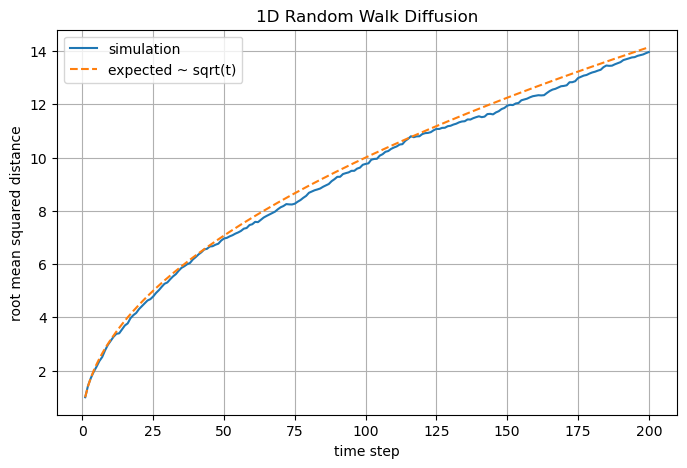

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_walkers = 1000
n_steps = 200

# 1. Create random steps: -1 or +1
steps = np.random.choice([-1, 1], size=(n_walkers, n_steps))

# 2. Compute the position of each walker at each time step
positions = np.cumsum(steps, axis=1)

# 3. Square the positions element-wise
squared_positions = positions**2

# 4. Compute the mean squared distance at each time step
mean_squared_distance = np.mean(squared_positions, axis=0)

# 5. Compute root mean squared distance
rms_distance = np.sqrt(mean_squared_distance)

# Time axis
time = np.arange(1, n_steps + 1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(time, rms_distance, label="simulation")
plt.plot(time, np.sqrt(time), linestyle="--", label="expected ~ sqrt(t)")

plt.xlabel("time step")
plt.ylabel("root mean squared distance")
plt.title("1D Random Walk Diffusion")
plt.legend()
plt.grid(True)
plt.show()

I represent the simulation as a 2D NumPy array where each row is one walker and each column is one time step. Each element is randomly chosen as -1 or +1. The position of each walker over time is obtained using np.cumsum along axis 1. Then I square the positions, average over all walkers using axis 0, and take the square root to obtain the typical distance from the origin as a function of time. The result should scale approximately as sqrt(t), which is the expected behavior of diffusion.

### Ex4.9



9\. Analyze a data file 
  * Download the population of hares, lynxes and carrots at the beginning of the last century.
    ```python
    ! wget https://www.dropbox.com/s/3vigxoqayo389uc/populations.txt
    ```

  * Check the content by looking within the file
  * Load the data (use an appropriate numpy method) into a 2D array
  * Create arrays out of the columns, the arrays being (in order): *year*, *hares*, *lynxes*, *carrots* 
  * Plot the 3 populations over the years
  * Compute the main statistical properties of the dataset (mean, std, correlations, etc.)
  * Which species has the highest population each year?

Do you feel there is some evident correlation here? [Studies](https://www.enr.gov.nt.ca/en/services/lynx/lynx-snowshoe-hare-cycle) tend to believe so.

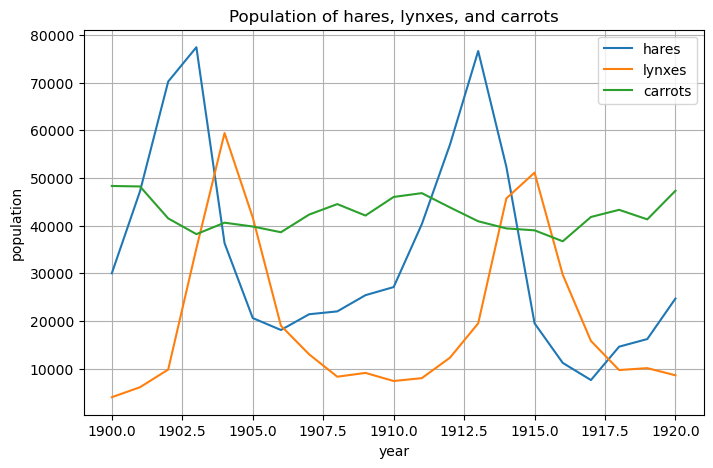

Mean population:
hares 34080.95238095238
lynxes 20166.666666666668
carrots 42400.0

Standard deviation:
hares 20897.906458089667
lynxes 16254.591536908763
carrots 3322.5062255844787

Minimum population:
hares 7600.0
lynxes 4000.0
carrots 36700.0

Maximum population:
hares 77400.0
lynxes 59400.0
carrots 48300.0

Correlation matrix:
[[ 1.          0.07189206 -0.01660378]
 [ 0.07189206  1.         -0.68057717]
 [-0.01660378 -0.68057717  1.        ]]

Species with highest population each year:
1900 carrots
1901 carrots
1902 hares
1903 hares
1904 lynxes
1905 lynxes
1906 carrots
1907 carrots
1908 carrots
1909 carrots
1910 carrots
1911 carrots
1912 hares
1913 hares
1914 hares
1915 lynxes
1916 carrots
1917 carrots
1918 carrots
1919 carrots
1920 carrots


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.loadtxt("populations.txt")

# Split columns
years = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]

# Put populations together
populations = data[:, 1:]
species = np.array(["hares", "lynxes", "carrots"])

# 1. Plot the 3 populations over the years
plt.figure(figsize=(8, 5))
plt.plot(years, hares, label="hares")
plt.plot(years, lynxes, label="lynxes")
plt.plot(years, carrots, label="carrots")

plt.xlabel("year")
plt.ylabel("population")
plt.title("Population of hares, lynxes, and carrots")
plt.legend()
plt.grid(True)
plt.show()

# 2. Main statistical properties
means = np.mean(populations, axis=0)
stds = np.std(populations, axis=0)
mins = np.min(populations, axis=0)
maxs = np.max(populations, axis=0)

print("Mean population:")
for name, value in zip(species, means):
    print(name, value)

print("\nStandard deviation:")
for name, value in zip(species, stds):
    print(name, value)

print("\nMinimum population:")
for name, value in zip(species, mins):
    print(name, value)

print("\nMaximum population:")
for name, value in zip(species, maxs):
    print(name, value)

# 3. Correlation matrix
correlations = np.corrcoef(populations.T)

print("\nCorrelation matrix:")
print(correlations)

# 4. Which species has the highest population each year?
highest_index = np.argmax(populations, axis=1)
highest_species = species[highest_index]

print("\nSpecies with highest population each year:")
for year, name in zip(years.astype(int), highest_species):
    print(year, name)
